# Phase 12: Backend API

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Expose the Phase 10 RAG chain and Phase 11 safety guardrails through a FastAPI `/chat` endpoint.

The notebook imports `07_backend/12_api_main.py` and exercises the same long-lived `ChatService` used by the web application. The default offline provider makes the walkthrough private, reproducible, and free of hosted-model charges.


## Inputs and numbered outputs

**Runtime inputs**

- `05_vector_store/chroma_db/06_vector_index.sqlite3`: searchable hospital evidence.
- `02_config/prompt_config.yaml`: safe prompt policy.
- `.env`: provider and model configuration.
- `01_data/sample_queries/test_questions.csv`: synthetic API evaluation requests.

**Outputs**

- `12_api_responses.json`: guarded response payloads returned by the chat service.
- `12_api_report.json`: endpoint-level counts, latency, configuration, and dependency availability.
- `12_api_audit.csv`: privacy-conscious operational audit without question or answer text.
- `12_failed_api_requests.json`: sanitized failed-request records.
- `plots/12_api_request_latency.png`: end-to-end request latency.
- `plots/12_api_safety_actions.png`: pass and override counts after final guardrails.


In [10]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = []
    for directory in (resolved, *resolved.parents):
        candidates.extend((directory, directory / "hospital_patient_helpdesk_chatbot"))
    for candidate in candidates:
        module_path = candidate / "07_backend" / "12_api_main.py"
        index_path = candidate / "05_vector_store" / "chroma_db" / "06_vector_index.sqlite3"
        if module_path.is_file() and index_path.is_file():
            return candidate
    raise FileNotFoundError("Could not locate the Hospital Patient Helpdesk Chatbot project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "07_backend" / "12_api_main.py"
QUESTIONS_PATH = PROJECT_ROOT / "01_data" / "sample_queries" / "test_questions.csv"
OUTPUT_DIR = PROJECT_ROOT / "01_data" / "processed"

spec = importlib.util.spec_from_file_location("phase12_api_main", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module: {MODULE_PATH}")
api_main = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = api_main
spec.loader.exec_module(api_main)

print(f"Project root: {PROJECT_ROOT}")
print(f"API module: {MODULE_PATH}")
print(f"FastAPI available: {importlib.util.find_spec('fastapi') is not None}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
API module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\07_backend\12_api_main.py
FastAPI available: False


## API architecture

`ChatService` owns initialized Phase 10 and Phase 11 dependencies so the vector index, prompt policy, provider configuration, and embedding modules are not reloaded for every request. `create_app()` is a thin FastAPI adapter that adds request and response models, `/`, `/health`, `/chat`, OpenAPI documentation, sanitized errors, and no-store security headers.


In [11]:
config = api_main.ApiConfig(provider="offline")
service = api_main.ChatService(PROJECT_ROOT, config)
health = service.health()

assert health["status"] == "ready"
assert health["index_ready"] is True
assert health["provider"] == "offline"

print(json.dumps(health, indent=2))


{
  "status": "ready",
  "service": "hospital-patient-helpdesk-chatbot",
  "api_version": "1.0",
  "provider": "offline",
  "model": "offline-grounded-v1",
  "index_ready": true,
  "guardrail_version": "1.0",
  "timestamp_utc": "2026-06-15T19:33:43.949975+00:00"
}


## Request validation

The framework-independent request contract trims repeated whitespace, requires 2–1000 question characters, limits optional filters to 100 characters, and ignores unknown fields. FastAPI adds JSON parsing and schema validation when installed.


In [12]:
request = api_main.ChatRequest.from_mapping({
    "question": "  Where   is the cardiology department?  ",
    "unknown_field": "discarded",
})

assert request.question == "Where is the cardiology department?"
print(request)

try:
    api_main.ChatRequest.from_mapping({"question": "x"})
except ValueError as error:
    print(f"Expected validation error: {error}")


ChatRequest(question='Where is the cardiology department?', department=None, content_category=None)
Expected validation error: question must contain at least 2 characters.


## Grounded `/chat` behavior

The service returns only the post-guardrail response. Safe grounded answers preserve their citations and source records.


In [13]:
grounded_response = service.chat(request)

assert grounded_response["mode"] == "grounded_answer"
assert grounded_response["guardrail_action"] == "pass"
assert grounded_response["citations"]
assert grounded_response["sources"]

print(json.dumps(grounded_response, indent=2, ensure_ascii=False))


{
  "request_id": "REQ-6A6804A1B7D2",
  "answer": "department_name: Cardiology | location: Level 3, West Wing | phone: 555-0110 | hours: Mon-Fri 08:00-17:00 | services: Outpatient heart-care consultations [S1]",
  "mode": "grounded_answer",
  "citations": [
    "[S1]"
  ],
  "sources": [
    {
      "citation": "[S1]",
      "chunk_id": "tabular-department-info-csv-0003-chunk-001",
      "source_file": "tabular/department_info.csv",
      "source_type": "csv",
      "department": "Cardiology",
      "content_category": "department_information",
      "page_reference": null,
      "score": 0.66274612
    },
    {
      "citation": "[S2]",
      "chunk_id": "tabular-department-info-csv-0001-chunk-001",
      "source_file": "tabular/department_info.csv",
      "source_type": "csv",
      "department": "Emergency Department",
      "content_category": "department_information",
      "page_reference": null,
      "score": 0.56991368
    },
    {
      "citation": "[S3]",
      "chunk_id": "

## Emergency `/chat` behavior

Possible emergencies are replaced by the approved Phase 11 routing message. Retrieved citations and sources are removed because the replacement is safety policy text, not a factual answer drawn from evidence.


In [14]:
emergency_request = api_main.ChatRequest.from_mapping({
    "question": "I have severe chest pain. What is wrong with me?"
})
emergency_response = service.chat(emergency_request)

assert emergency_response["mode"] == "emergency"
assert emergency_response["guardrail_action"] == "override"
assert emergency_response["risk_level"] == "critical"
assert emergency_response["citations"] == []
assert emergency_response["sources"] == []

print(json.dumps(emergency_response, indent=2, ensure_ascii=False))


{
  "request_id": "REQ-233F835CF73F",
  "answer": "Contact local emergency services immediately or go to the nearest emergency department. I cannot diagnose the cause of these symptoms.",
  "mode": "emergency",
  "citations": [],
  "sources": [],
  "retrieval_confidence": "medium",
  "safety_flag": true,
  "guardrail_action": "override",
  "risk_level": "critical",
  "triggered_rules": [
    "GR-001_EMERGENCY_ROUTING"
  ],
  "provider": "offline",
  "model": "offline-grounded-v1",
  "latency_ms": 3.22,
  "timestamp_utc": "2026-06-15T19:33:44.020999+00:00"
}


## FastAPI application contract

When FastAPI and Pydantic are installed, `create_app()` creates `/`, `/health`, and `/chat`, with generated OpenAPI documentation at `/docs`. The current environment check is explicit so a missing web dependency does not prevent core service validation.


In [15]:
FASTAPI_AVAILABLE = importlib.util.find_spec("fastapi") is not None

if FASTAPI_AVAILABLE:
    application = api_main.create_app(PROJECT_ROOT, config)
    paths = application.openapi()["paths"]
    assert "/chat" in paths and "post" in paths["/chat"]
    assert "/health" in paths and "get" in paths["/health"]
    print(json.dumps(sorted(paths), indent=2))
else:
    assert api_main.app is None
    print("FastAPI is not installed; the shared ChatService remains fully testable.")


FastAPI is not installed; the shared ChatService remains fully testable.


## Run the complete Phase 12 evaluation

The evaluation sends all 12 synthetic questions through the same service used by `/chat`, writes guarded payloads and privacy-conscious audit rows, and creates both numbered diagnostics.


In [16]:
result = api_main.run_api_evaluation(
    questions_path=QUESTIONS_PATH,
    output_dir=OUTPUT_DIR,
    project_root=PROJECT_ROOT,
    config=config,
)

assert result.requests_input == 12
assert result.responses_created == 12
assert result.failed_requests == 0

print(f"Input requests: {result.requests_input}")
print(f"Responses created: {result.responses_created}")
print(f"Failed requests: {result.failed_requests}")


Input requests: 12
Responses created: 12
Failed requests: 0


## Validate output contracts

The expected sample contains nine grounded passes and three safety overrides. Every response requires a request ID, non-empty answer, guardrail action, risk level, latency, and timestamp.


In [17]:
responses = json.loads(result.responses_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
failures = json.loads(result.failed_path.read_text(encoding="utf-8"))

assert len(responses) == 12
assert failures == []
assert report["safety_action_counts"] == {"override": 3, "pass": 9}
assert report["mode_counts"] == {
    "emergency": 1,
    "grounded_answer": 9,
    "unsafe_medical_advice": 2,
}
assert all(item["request_id"] and item["answer"].strip() for item in responses)

print(json.dumps(report, indent=2))


{
  "generated_at_utc": "2026-06-15T19:33:44.445495+00:00",
  "api_version": "1.0",
  "questions_input": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\sample_queries\\test_questions.csv",
  "requests_input": 12,
  "responses_created": 12,
  "failed_requests": 0,
  "provider": "offline",
  "model": "offline-grounded-v1",
  "mode_counts": {
    "emergency": 1,
    "grounded_answer": 9,
    "unsafe_medical_advice": 2
  },
  "safety_action_counts": {
    "override": 3,
    "pass": 9
  },
  "latency_ms": {
    "minimum": 2.65,
    "maximum": 14.034,
    "mean": 5.046,
    "median": 4.357
  },
  "fastapi_available": false,
  "configuration": {
    "provider": "offline",
    "top_k": 3,
    "host": "127.0.0.1",
    "port": 8000
  },
  "output_files": [
    "12_api_responses.json",
    "12_api_report.json",
    "12_api_audit.csv",
    "12_failed_api_requests.json",
    "plots/12_api_request_latency.png",
    "plots/12_api_safety_a

## Diagnostic plots

Latency shows end-to-end service time across retrieval, prompting, generation, and guardrails. Safety actions confirm which responses passed unchanged or were overridden. These plots do not measure medical correctness.


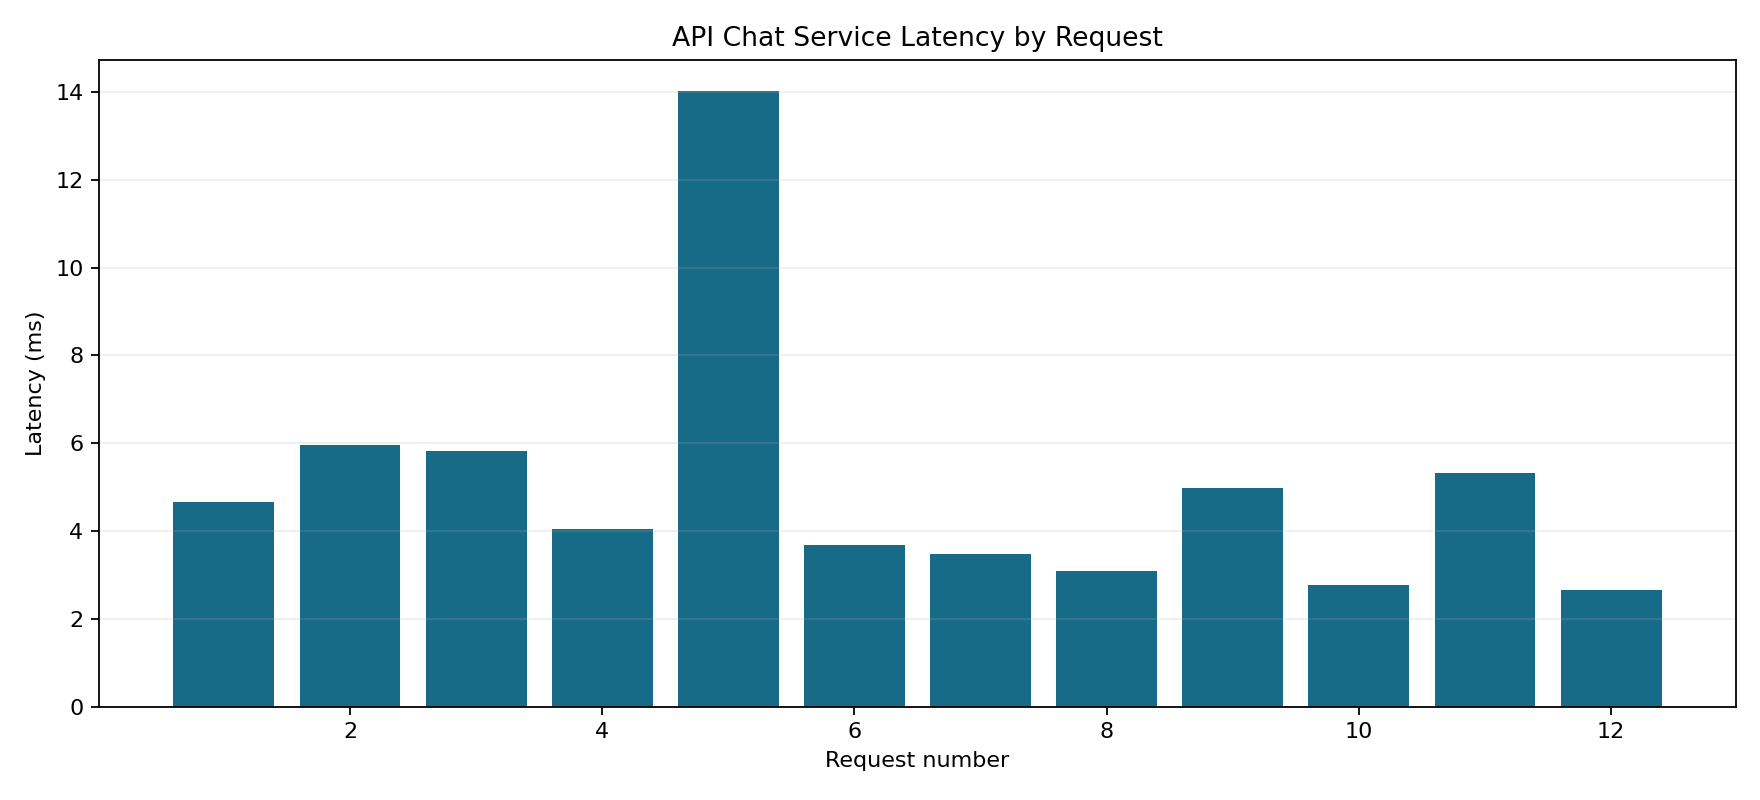

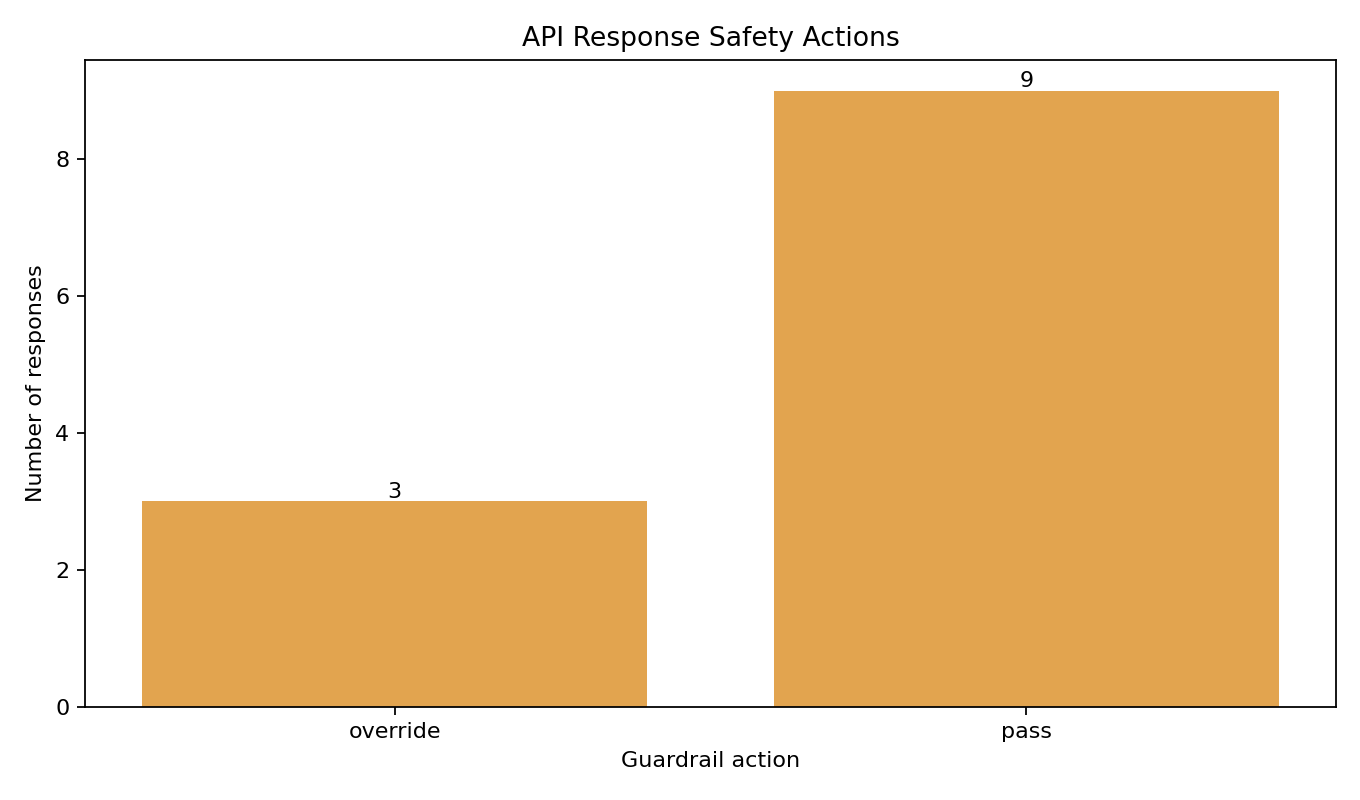

In [18]:
from IPython.display import Image, display

display(Image(filename=str(result.latency_plot_path)))
display(Image(filename=str(result.safety_plot_path)))


## Notebook and Python module responsibilities

- **Notebook:** architecture walkthrough, health and validation examples, grounded and emergency service calls, dependency-aware app inspection, batch assertions, reports, and plots.
- **Python module:** long-lived service initialization, request validation, FastAPI routes and models, security headers, sanitized errors, offline endpoint evaluation, artifacts, diagnostics, and server CLI.

Both use the same `ChatService`, so notebook results and `/chat` behavior stay aligned.

## Deployment boundary

Before public deployment, install pinned dependencies, use authentication and authorization, terminate HTTPS at a trusted proxy, restrict CORS, add rate limits and request-size limits, centralize privacy-conscious logs, protect secrets, monitor failures, and complete security, privacy, clinical-safety, and operational reviews. The API is informational and must not be represented as emergency care or clinical decision support.
